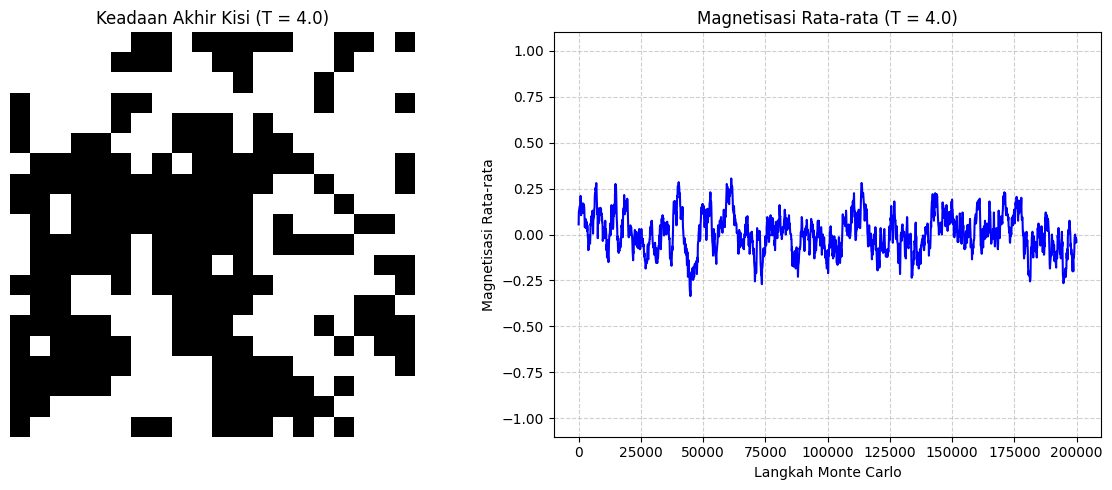

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETER SISTEM
# ==========================================
N = 20                # Ukuran kisi 20x20
MCS = 200000          # Total langkah Monte Carlo
T = 4.0               # SUHU SISTEM

# Inisialisasi Hot Start (Spin acak -1 atau 1) untuk entropi maksimum
grid = np.random.choice([-1, 1], size=(N, N))

mag_history = []      # Array untuk menyimpan nilai magnetisasi

# ==========================================
# 2. ALGORITMA METROPOLIS
# ==========================================
for step in range(MCS):
    # Pilih koordinat kisi secara acak
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)
    s = grid[i, j]

    # Hitung spin tetangga dengan Kondisi Batas Periodik (menggunakan modulo)
    tetangga = grid[(i+1)%N, j] + grid[(i-1)%N, j] + grid[i, (j+1)%N] + grid[i, (j-1)%N]

    # Hitung selisih energi lokal
    delta_E = 2 * s * tetangga

    # Kriteria penerimaan Metropolis
    if delta_E < 0:
        s *= -1 # Terima pembalikan spin
    elif np.random.rand() < np.exp(-delta_E / T):
        s *= -1 # Terima dengan probabilitas tertentu

    grid[i, j] = s # Update kisi

    # Catat rata-rata magnetisasi setiap 100 langkah
    if step % 100 == 0:
        mag_history.append(np.sum(grid) / (N**2))

# ==========================================
# 3. VISUALISASI HASIL
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Keadaan Akhir Kisi (Peta Warna Biner)
axes[0].imshow(grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f"Keadaan Akhir Kisi (T = {T})")
axes[0].axis('off')

# Plot 2: Riwayat Magnetisasi
# Sumbu X: Langkah Monte Carlo (x100), Sumbu Y: Magnetisasi
axes[1].plot(range(0, MCS, 100), mag_history, color='blue', linewidth=1.5)
axes[1].set_title(f"Magnetisasi Rata-rata (T = {T})")
axes[1].set_xlabel("Langkah Monte Carlo")
axes[1].set_ylabel("Magnetisasi Rata-rata")
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**ANALISIS**

Pada suhu tinggi (T > Tc) , energi termal dari lingkungan sangat mendominasi dan mengalahkan energi interaksi antar-spin. Akibatnya, orientasi dari partikel-partikel spin menjadi sangat acak dan tidak lagi saling bergantung. Secara visual, peta warna biner menampilkan pola acak (noise) tanpa adanya struktur domain besar yang terbentuk. Kondisi keacakan sempurna ini dibuktikan oleh kurva riwayat magnetisasi rata-rata yang anjlok dan bergerak fluktuatif di sekitar angka nol (|M| ≈ 0). Hal ini membuktikan bahwa pada fase paramagnetik, sistem kehilangan sifat magnetisasi spontan secara makroskopis.